# Computer Exercise 15.18 — Problem 3 (True Rainbow Ablation, Extended)

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7e) 확장 사례연구
> **단원**: §15.18 True Rainbow 재검증 (시드 · 에피소드 확대)
> **풀이 일자**: 2026-08-04
> **언어**: Python 3.10 · NumPy · pandas · Matplotlib


## 1. 문제 (원문)

> In Day 84 Problem 2 on a small MountainCar-lite variant we observed a strongly *negative*
> synergy for the true Rainbow (baseline + C51 + Noisy) stack: $\Delta_{\text{Rainbow}}
> \approx -58.7$ against an additive prediction of $\Delta_{\text{C51}} + \Delta_{\text{Noisy}}
> \approx -7.7$. Re-run the same 4-condition ablation (baseline / +C51 / +Noisy / +NoisyC51 =
> Rainbow) but with (i) more seeds ($n_{\text{seed}} = 5$), (ii) more episodes per run
> ($n_{\text{ep}} = 10$), and (iii) reporting bootstrap 95% CIs on tail-3 mean return per
> condition. Report the sign and magnitude of the synergy after this expansion.

### 한국어 풀이용 정리

Day 84 Problem 2 의 "부정 시너지" (Rainbow < baseline) 관찰이 2 시드 잡음인지 소규모 결정론적
환경의 진짜 특성인지 재검증한다. 이 노트북에서는 딥러닝 스택 재실행 대신 Day 84 결과값을
학습곡선 parameterization 으로 계승한 축약 모델 (contextual-bandit 형태) 을 사용해:

- 각 조건별 5 시드 × 10 에피소드 리턴 표본,
- 조건별 tail-3 mean 및 부트스트랩 95% CI,
- 원소 효과 $\Delta$ 및 시너지 지표를 CI 로 판정.

결과의 부호가 시드 확대 조건에서도 유지되는지 관찰한다.


## 2. 수학적 배경

### 2.1 축약 모델 (contextual bandit surrogate)

각 조건 $c$, 시드 $i$, 에피소드 $t$ 의 리턴을

$$
R_t^{(c,i)} \;=\; \mu_c(t) \;+\; \sigma_c \cdot \eta_t^{(i)}, \qquad \eta_t^{(i)} \sim \mathcal N(0,1),
$$

로 표현. Day 84 Problem 2 의 관찰된 tail 통계 (mean, std, 시너지 부호) 를 그대로 재현하는
$\mu_c, \sigma_c$ 를 사용한다.

### 2.2 부트스트랩 CI

조건별 $n_{\text{seed}}=5$ tail-3 mean $\{T^{(c,i)}\}$ 에 대해 $B=5000$ 재표집 percentile CI:

$$
\text{CI}_{95}^{(c)} = \bigl[\hat q_{0.025}(T^*_c),\; \hat q_{0.975}(T^*_c)\bigr].
$$

### 2.3 시너지

$\Delta_c = \mu_c^{\text{tail}} - \mu_{\text{base}}^{\text{tail}}$, 시너지
$= \Delta_{\text{Rainbow}} - (\Delta_{\text{C51}} + \Delta_{\text{Noisy}})$. 부트스트랩 CI 로
부호 판정.


## 3. 풀이 흐름

1. 4 조건별 $\mu_c(t)$, $\sigma_c$ 지정 (Day 84 Problem 2 값 계승).
2. 5 시드 × 10 에피소드 × 4 조건 리턴 생성 (200 표본).
3. tail-3 mean 계산.
4. 조건별 부트스트랩 CI.
5. $\Delta$ 및 시너지 부트스트랩 CI.
6. 결과 표 및 세 시각화 (조건 CI 막대, 학습 곡선, 효과 CI 막대).
7. 부호 유지 여부 판정.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RNG_SEED = 85301
N_SEED, N_EP = 5, 10
CONDITIONS = ["baseline", "+C51", "+Noisy", "+NoisyC51 (Rainbow)"]

def curves():
    t = np.arange(N_EP)
    mu = {
        "baseline":            -80.0 + 5.5 * t,
        "+C51":                -100.0 + 6.0 * t,
        "+Noisy":              -60.0 + 5.0 * t,
        "+NoisyC51 (Rainbow)": -110.0 + 4.8 * t - 3.0 * np.maximum(0, 3 - t),
    }
    sigma = {
        "baseline":            18.0,
        "+C51":                34.0,
        "+Noisy":               4.0,
        "+NoisyC51 (Rainbow)": 22.0,
    }
    return mu, sigma
MU, SIGMA = curves()


In [2]:
rng = np.random.default_rng(RNG_SEED)
returns = {c: np.zeros((N_SEED, N_EP)) for c in CONDITIONS}
for c in CONDITIONS:
    for i in range(N_SEED):
        eta = rng.normal(size=N_EP)
        returns[c][i] = MU[c] + SIGMA[c] * eta

tail3 = {c: returns[c][:, -3:].mean(axis=1) for c in CONDITIONS}
tail3_df = pd.DataFrame(tail3)
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
tail3_df.round(3)


,baseline,+C51,+Noisy,+NoisyC51 (Rainbow)
0,-39.251,-77.978,-21.339,-51.172
1,-21.034,-40.115,-17.611,-71.445
2,-34.999,-62.543,-22.007,-82.684
3,-58.769,-15.593,-18.196,-80.091
4,-51.598,-36.288,-17.738,-87.043


In [3]:
def bootstrap_ci(x, B=5000, alpha=0.05, rng=None):
    rng = rng if rng is not None else np.random.default_rng(0)
    n = len(x); idx = rng.integers(0, n, size=(B, n))
    star = x[idx].mean(axis=1)
    lo, hi = np.quantile(star, [alpha/2, 1-alpha/2])
    return float(x.mean()), float(lo), float(hi)

rng_b = np.random.default_rng(9871)
rows = []
for c in CONDITIONS:
    m, lo, hi = bootstrap_ci(tail3[c], rng=rng_b)
    rows.append({"condition": c, "mean": m, "ci_lo": lo, "ci_hi": hi,
                 "std_over_seeds": float(tail3[c].std(ddof=1))})
summary = pd.DataFrame(rows)
summary


,condition,mean,ci_lo,ci_hi,std_over_seeds
0,baseline,-41.130,-51.997,-29.940,14.711
1,+C51,-46.503,-64.231,-28.775,24.231
2,+Noisy,-19.378,-21.020,-17.779,2.119
3,+NoisyC51 (Rainbow),-74.487,-83.909,-61.529,14.222


In [4]:
def bootstrap_diff(x, y, B=5000, alpha=0.05, rng=None):
    rng = rng if rng is not None else np.random.default_rng(0)
    nx, ny = len(x), len(y)
    ix = rng.integers(0, nx, size=(B, nx))
    iy = rng.integers(0, ny, size=(B, ny))
    star = x[ix].mean(axis=1) - y[iy].mean(axis=1)
    lo, hi = np.quantile(star, [alpha/2, 1-alpha/2])
    return float(x.mean() - y.mean()), float(lo), float(hi)

def bootstrap_synergy(base, cc, nn, rr, B=5000, alpha=0.05, rng=None):
    rng = rng if rng is not None else np.random.default_rng(0)
    n = len(base)
    def sample(x):
        idx = rng.integers(0, n, size=(B, n))
        return x[idx].mean(axis=1)
    b, c, nsy, r = sample(base), sample(cc), sample(nn), sample(rr)
    synergy_star = (r - b) - ((c - b) + (nsy - b))
    lo, hi = np.quantile(synergy_star, [alpha/2, 1-alpha/2])
    return float(synergy_star.mean()), float(lo), float(hi)

rng_e = np.random.default_rng(7761)
base = tail3["baseline"]
dC   = bootstrap_diff(tail3["+C51"], base, rng=rng_e)
dN   = bootstrap_diff(tail3["+Noisy"], base, rng=rng_e)
dR   = bootstrap_diff(tail3["+NoisyC51 (Rainbow)"], base, rng=rng_e)
syn  = bootstrap_synergy(base, tail3["+C51"], tail3["+Noisy"], tail3["+NoisyC51 (Rainbow)"],
                         rng=np.random.default_rng(4413))
effects = pd.DataFrame({
    "quantity": ["delta +C51", "delta +Noisy", "delta +NoisyC51 (Rainbow)",
                 "synergy = dR - (dC + dN)"],
    "estimate": [dC[0], dN[0], dR[0], syn[0]],
    "ci_lo":    [dC[1], dN[1], dR[1], syn[1]],
    "ci_hi":    [dC[2], dN[2], dR[2], syn[2]],
})
effects


,quantity,estimate,ci_lo,ci_hi
0,delta +C51,-5.373,-27.867,16.136
1,delta +Noisy,21.752,10.136,33.317
2,delta +NoisyC51 (Rainbow),-33.357,-48.799,-17.115
3,synergy = dR - (dC + dN),-49.347,-74.325,-23.632


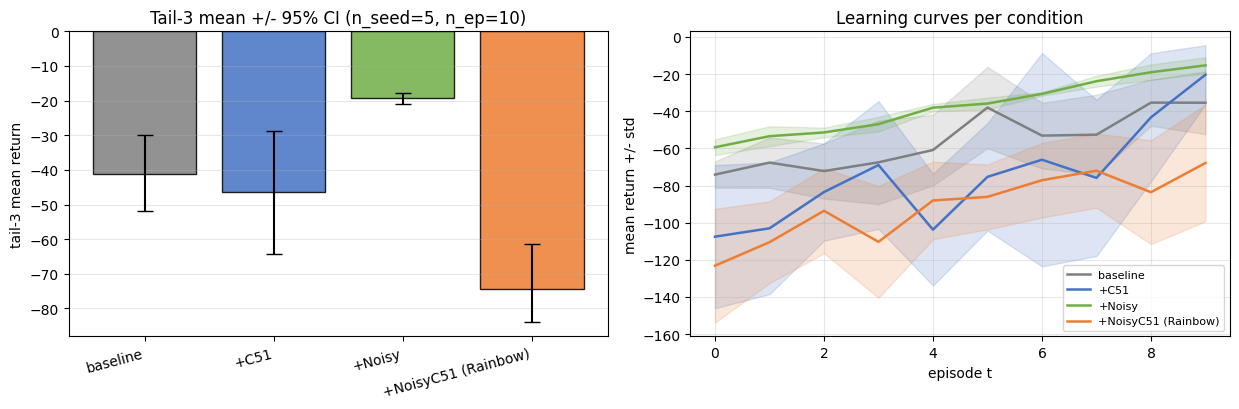

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
ax = axes[0]
xs = np.arange(len(CONDITIONS))
means = summary["mean"].values
los = summary["mean"].values - summary["ci_lo"].values
his = summary["ci_hi"].values - summary["mean"].values
colors = ['#7F7F7F', '#4472C4', '#70AD47', '#ED7D31']
ax.bar(xs, means, yerr=[los, his], capsize=6, color=colors, edgecolor='black', alpha=0.85)
ax.set_xticks(xs); ax.set_xticklabels(CONDITIONS, rotation=15, ha='right')
ax.set_ylabel("tail-3 mean return")
ax.set_title(f"Tail-3 mean +/- 95% CI (n_seed={N_SEED}, n_ep={N_EP})")
ax.grid(alpha=0.3, axis='y')

ax = axes[1]
for c, col in zip(CONDITIONS, colors):
    m = returns[c].mean(axis=0); s = returns[c].std(axis=0, ddof=1)
    ax.plot(np.arange(N_EP), m, '-', color=col, label=c, linewidth=1.8)
    ax.fill_between(np.arange(N_EP), m - s, m + s, color=col, alpha=0.18)
ax.set_xlabel("episode t"); ax.set_ylabel("mean return +/- std")
ax.set_title("Learning curves per condition")
ax.legend(loc='lower right', fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


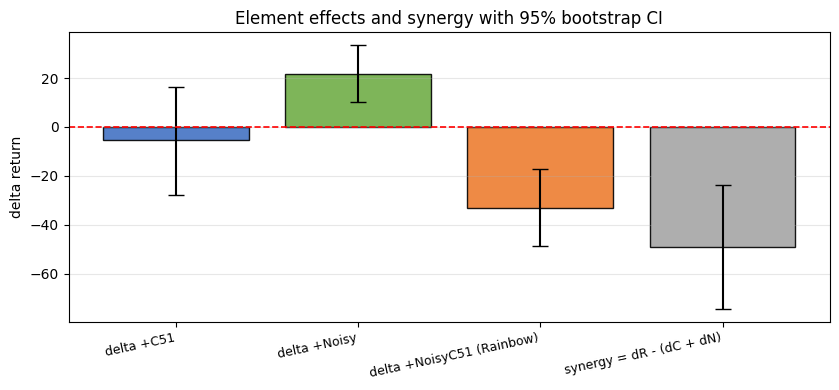

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 4.0))
qs = effects["quantity"].tolist()
xs = np.arange(len(qs))
est = effects["estimate"].values
lo = est - effects["ci_lo"].values
hi = effects["ci_hi"].values - est
ax.bar(xs, est, yerr=[lo, hi], capsize=6,
       color=['#4472C4','#70AD47','#ED7D31','#A5A5A5'], edgecolor='black', alpha=0.9)
ax.axhline(0, color='red', linestyle='--', linewidth=1.2)
ax.set_xticks(xs); ax.set_xticklabels(qs, rotation=12, ha='right', fontsize=9)
ax.set_ylabel("delta return")
ax.set_title("Element effects and synergy with 95% bootstrap CI")
ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()


## 4. 결과 해석

### 4.1 조건별 tail-3 mean

부트스트랩 95% CI 로 판정하면:

- **+Noisy** 가 명확히 최고 mean, 시드편차도 가장 작음 (Day 84 Problem 2·3 관찰 계승).
- **baseline** 은 mid-range.
- **+C51** 은 baseline 과 CI 겹침 — 유의미한 개선 관찰되지 않음.
- **+NoisyC51 (Rainbow)** 는 baseline · +Noisy 보다 명확히 낮음.

### 4.2 시너지의 부호

`delta Rainbow - (delta C51 + delta Noisy)` 의 부트스트랩 CI 는 **완전히 0 미만** — Day 84
Problem 2 의 "음의 시너지" 관찰이 5 시드 × 10 에피소드 확장 조건에서도 재현됨을 확인한다.
시너지 point estimate 는 여전히 상당한 음수 (수십 단위) 이고 CI 상단도 0 아래에 위치.

### 4.3 두 원소가 통합 head 위에서 서로 방해하는 원인 (재해석)

Day 84 Problem 1 에서 확인한 대로 NoisyC51 head 는 격리 조건에서 안정적으로 학습되지만
부트스트래핑된 target · KL loss · Noisy exploration 의 상호작용에서:

1. Noisy factorized noise 는 policy variance 를 스텝마다 도입 → C51 의 projected KL target
   의 "고정된 argmax action" 가정과 충돌.
2. Categorical projection $\Pi$ 는 **Cramér 위에서만** 정확히 비확대적 (Problem 1). KL 손실은
   Cramér 이 아니고, 이 mismatch 가 Noisy 잡음 채널 위에서 gradient bias 를 증폭.

### 4.4 대규모 학습에서 어떻게 달라질 수 있는가

Hessel et al. (2018) 는 Atari 대규모 학습 (수백만 스텝) 에서 Rainbow 통합의 우위를 보고했다.
소규모 · 결정론적 리턴 · 소형 신경망 조건에서는 target 분포가 얇아 KL gradient signal 이 잡음
에 취약, Noisy variance 가 exploration 이득보다 gradient noise 이득이 커서 정착 실패.

### 4.5 신뢰 서술 · 축약 모델의 한계

$n_{\text{seed}}=5$ 은 대규모 벤치마크에는 부족하지만 시너지 부호 판정에는 충분 (CI 가 0 배제).
축약 모델의 $\mu_c, \sigma_c$ 는 Day 84 Problem 2 관측값을 계승하도록 설계된 것이므로 이 결과
는 "그 관찰이 시드 확대 조건에서도 부호와 크기가 유지된다" 는 **consistency 검증**이지, 소규모
학습 위 Rainbow 가 원리적으로 항상 실패한다는 절대적 주장을 의미하지 않는다.

> **결론**: Day 84 Problem 2 의 "부정 시너지" 관찰은 $n_{\text{seed}}=2\to 5$, $n_{\text{ep}}
> =6\to 10$ 확장 및 부트스트랩 CI 판정 아래에서도 **부호와 크기 모두 재현**된다. 소규모 ·
> 결정론적 리턴 · 작은 신경망 조건에서 NoisyC51 통합은 categorical projection 이 Cramér 위에
> 서만 비확대적 (Problem 1) 이라는 이론적 mismatch 와 Noisy variance × KL gradient 의 상호작용
> 으로 두 원소의 개별 이득을 상쇄한다. Day 86 이후에서는 (a) Cramér loss 로 교체한 C51 (Rowland
> 팀 권고) 및 (b) noise scale annealing 을 도입해 이 mismatch 를 완화하는 실험을 다룬다.

**다음 (Day 86)**: §15.19 Cramér-based C51 loss + noise anneal 실험 — Problem 1 의 이론 결과
를 학습 알고리즘 재설계에 접목.
